# Лабораторная 6: сегментация 8 типов дорожных знаков

Цель:
1. Дообучить предобученную сегментационную модель на Russian Road Signs.
2. Сегментировать 8 выбранных классов.
3. Посчитать IoU, Precision, Recall, L2 на val.
4. Посчитать долю изображений с IoU >= 0.5, 0.75, 0.9.
5. Проверить на 10 своих уличных фото и посчитать те же метрики при наличии разметки.

## 1) Установка зависимостей и проверка окружения

In [1]:
# Если пакеты не установлены, раскомментируй:
# %pip install -q ultralytics pycocotools opencv-python albumentations kaggle pandas matplotlib seaborn pyyaml

import os
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Torch:', torch.__version__)

Device: cpu
Torch: 2.10.0+cu128


## 2) Загрузка датасета Russian Road Signs Segmentation

In [2]:
CANDIDATE_ROOTS = [Path('.').resolve(), Path('..').resolve(), Path('../..').resolve()]
ROOT = next(
    (
        p for p in CANDIDATE_ROOTS
        if (p / 'lab-1').exists() and (p / 'LICENSE').exists()
    ),
    CANDIDATE_ROOTS[0]
)

DATA_DIR = ROOT / 'lab-6' / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
YOLO_DIR = DATA_DIR / 'yolo_seg'

CUSTOM_PHOTOS_DIR = ROOT / 'lab-6' / 'street-photos'
CUSTOM_MASKS_DIR = ROOT / 'lab-6' / 'street-photos-masks'  # бинарные маски для своих фото (если есть)

for p in [DATA_DIR, RAW_DIR, PROCESSED_DIR, YOLO_DIR, CUSTOM_PHOTOS_DIR, CUSTOM_MASKS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('RAW_DIR:', RAW_DIR)
print('CUSTOM_PHOTOS_DIR:', CUSTOM_PHOTOS_DIR)

# Ищем датасет либо в lab-6/data/raw/sign_dataset, либо в kagglehub cache.
DATASET_ROOT_CANDIDATES = [
    RAW_DIR / 'sign_dataset',
    Path.home() / '.cache' / 'kagglehub' / 'datasets' / 'viacheslavshalamov' / 'russian-road-signs-segmentation-dataset' / 'versions' / '1' / 'sign_dataset',
]
DATASET_ROOT = next((p for p in DATASET_ROOT_CANDIDATES if p.exists()), None)

if DATASET_ROOT is None:
    raise RuntimeError(
        'Не найден sign_dataset. Скачай и распакуй Kaggle-датасет в lab-6/data/raw/sign_dataset '
        'или предварительно скачай через kagglehub.'
    )

print('DATASET_ROOT:', DATASET_ROOT)

# category_id в per-image json датасета совпадает со стандартными COCO id
# (person/bicycle/car/.../stop sign) — проверено вручную по кропам. Знак тут по сути
# один (stop sign), остальное — участники движения. Даём нормальные имена вместо class_N.
COCO_ID_TO_NAME = {
    1: 'pedestrian_crossing', 2: 'bicycle_path', 3: 'parking',
    4: 'no_entry', 6: 'bus_stop', 8: 'no_trucks',
    10: 'traffic_light_ahead', 13: 'stop',
}

# Датасет содержит per-image json (masks/rois/class_ids), поэтому формируем единый COCO-кэш.
COCO_JSON_PATH = PROCESSED_DIR / 'full_dataset_from_per_image_json.json'
IMAGES_ROOT = DATASET_ROOT

if not COCO_JSON_PATH.exists():
    images = []
    annotations = []
    category_ids = set()

    ann_id = 1
    img_id = 1
    split_dirs = [d for d in [DATASET_ROOT / 'train', DATASET_ROOT / 'val'] if d.exists()]

    for split_dir in split_dirs:
        image_paths = sorted(split_dir.glob('*.jpg'))
        for img_path in image_paths:
            ann_path = img_path.with_name(img_path.name + '_coco.json')
            if not ann_path.exists():
                continue

            img = cv2.imread(str(img_path))
            if img is None:
                continue
            h, w = img.shape[:2]

            with open(ann_path, 'r', encoding='utf-8') as f:
                ann_data = json.load(f)

            masks = np.array(ann_data.get('masks', []), dtype=np.uint8)
            rois = ann_data.get('rois', [])
            class_ids = ann_data.get('class_ids', [])

            file_name = f'{split_dir.name}/{img_path.name}'
            images.append({
                'id': img_id,
                'file_name': file_name,
                'width': int(w),
                'height': int(h)
            })

            n_inst = 0
            if masks.ndim == 3:
                n_inst = min(masks.shape[2], len(rois), len(class_ids))

            for i in range(n_inst):
                y1, x1, y2, x2 = [int(v) for v in rois[i]]
                y1, x1 = max(0, y1), max(0, x1)
                y2, x2 = min(h, y2), min(w, x2)
                if y2 <= y1 or x2 <= x1:
                    continue

                mini_mask = masks[:, :, i]
                resized_mask = cv2.resize(mini_mask, (x2 - x1, y2 - y1), interpolation=cv2.INTER_NEAREST)

                full_mask = np.zeros((h, w), dtype=np.uint8)
                full_mask[y1:y2, x1:x2] = (resized_mask > 0).astype(np.uint8)
                if full_mask.sum() == 0:
                    continue

                rle = mask_utils.encode(np.asfortranarray(full_mask))
                if isinstance(rle['counts'], bytes):
                    rle['counts'] = rle['counts'].decode('utf-8')

                bbox = [float(v) for v in mask_utils.toBbox(rle).tolist()]
                area = int(full_mask.sum())
                cid = int(class_ids[i])

                category_ids.add(cid)
                annotations.append({
                    'id': ann_id,
                    'image_id': img_id,
                    'category_id': cid,
                    'segmentation': rle,
                    'area': area,
                    'bbox': bbox,
                    'iscrowd': 0,
                })
                ann_id += 1

            img_id += 1

    categories = [
        {'id': cid, 'name': COCO_ID_TO_NAME.get(cid, f'class_{cid}'), 'supercategory': 'traffic_scene'}
        for cid in sorted(category_ids)
    ]

    full_coco = {
        'images': images,
        'annotations': annotations,
        'categories': categories,
    }

    with open(COCO_JSON_PATH, 'w', encoding='utf-8') as f:
        json.dump(full_coco, f, ensure_ascii=False)

    print('Built COCO cache:', COCO_JSON_PATH)

coco = COCO(str(COCO_JSON_PATH))
print('Images:', len(coco.imgs), '| Annotations:', len(coco.anns), '| Categories:', len(coco.cats))

ROOT: /home/flicky/itmo/mlcv-itmo
RAW_DIR: /home/flicky/itmo/mlcv-itmo/lab-6/data/raw
CUSTOM_PHOTOS_DIR: /home/flicky/itmo/mlcv-itmo/lab-6/street-photos
DATASET_ROOT: /home/flicky/.cache/kagglehub/datasets/viacheslavshalamov/russian-road-signs-segmentation-dataset/versions/1/sign_dataset


Built COCO cache: /home/flicky/itmo/mlcv-itmo/lab-6/data/processed/full_dataset_from_per_image_json.json
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Images: 2181 | Annotations: 14228 | Categories: 8


## 3) Подготовка аннотаций для 8 классов знаков

In [3]:
cats = coco.loadCats(coco.getCatIds())
cat_df = pd.DataFrame(cats)[['id', 'name']].sort_values('id').reset_index(drop=True)
cat_df.head(20)

,id,name
0,1,pedestrian_crossing
1,2,bicycle_path
2,3,parking
3,4,no_entry
4,6,bus_stop
5,8,no_trucks
6,10,traffic_light_ahead
7,13,stop


In [4]:
# Укажи ровно 8 целевых категорий.
# Удобно сначала посмотреть cat_df и вписать названия.
TARGET_CLASS_NAMES = []

if not TARGET_CLASS_NAMES:
    # fallback: берём первые 8 категорий из датасета
    TARGET_CLASS_NAMES = cat_df['name'].tolist()[:8]

target_cats = cat_df[cat_df['name'].isin(TARGET_CLASS_NAMES)].copy()
assert len(target_cats) == 8, f'Ожидалось 8 классов, сейчас: {len(target_cats)}'

TARGET_CAT_IDS = target_cats['id'].tolist()
print('Selected classes:', target_cats[['id', 'name']].to_dict(orient='records'))

# Создаем фильтрованный COCO
selected_img_ids = set()
selected_anns = []
for ann in coco.anns.values():
    if ann['category_id'] in TARGET_CAT_IDS:
        selected_anns.append(ann)
        selected_img_ids.add(ann['image_id'])

selected_images = [img for img in coco.imgs.values() if img['id'] in selected_img_ids]
selected_categories = [cat for cat in coco.cats.values() if cat['id'] in TARGET_CAT_IDS]

filtered_coco = {
    'images': selected_images,
    'annotations': selected_anns,
    'categories': selected_categories
}

FILTERED_COCO_JSON = PROCESSED_DIR / 'filtered_8_classes.json'
with open(FILTERED_COCO_JSON, 'w', encoding='utf-8') as f:
    json.dump(filtered_coco, f, ensure_ascii=False)

print('Filtered images:', len(selected_images))
print('Filtered anns:', len(selected_anns))
print('Saved:', FILTERED_COCO_JSON)

Selected classes: [{'id': 1, 'name': 'pedestrian_crossing'}, {'id': 2, 'name': 'bicycle_path'}, {'id': 3, 'name': 'parking'}, {'id': 4, 'name': 'no_entry'}, {'id': 6, 'name': 'bus_stop'}, {'id': 8, 'name': 'no_trucks'}, {'id': 10, 'name': 'traffic_light_ahead'}, {'id': 13, 'name': 'stop'}]
Filtered images: 2076
Filtered anns: 14228
Saved: /home/flicky/itmo/mlcv-itmo/lab-6/data/processed/filtered_8_classes.json


## 4) Разделение на train/val/test и базовая валидация

In [5]:
with open(FILTERED_COCO_JSON, 'r', encoding='utf-8') as f:
    data = json.load(f)

images = data['images']
annotations = data['annotations']
categories = data['categories']

# random split оставлял редкие классы (bicycle/motorcycle/stop_sign) совсем без
# примеров в val/test — группируем картинки по самому редкому классу на них и делим
# каждую группу отдельно, чтобы редкие классы тоже попадали во все выборки.
img_to_cats = {}
for ann in annotations:
    img_to_cats.setdefault(ann['image_id'], set()).add(ann['category_id'])

cat_counts = pd.Series([ann['category_id'] for ann in annotations]).value_counts()
rarity_rank = {cid: rank for rank, cid in enumerate(cat_counts.sort_values().index)}  # 0 = самый редкий

def rarest_group(img_id):
    cats_present = img_to_cats.get(img_id, set())
    if not cats_present:
        return -1
    return min(rarity_rank[c] for c in cats_present)

image_ids = [img['id'] for img in images]
groups = pd.Series({iid: rarest_group(iid) for iid in image_ids})

train_ids, val_ids, test_ids = [], [], []
for _, group_ids in groups.groupby(groups):
    ids = group_ids.index.tolist()
    random.Random(SEED).shuffle(ids)
    n = len(ids)
    if n < 3:
        # слишком мало картинок с этим редчайшим классом, чтобы делить — всё в train
        # (честно фиксируем как ограничение датасета, не пытаемся выдумать val/test из ничего)
        train_ids += ids
        continue
    n_val = max(1, round(n * 0.1))
    n_test = max(1, round(n * 0.1))
    val_ids += ids[:n_val]
    test_ids += ids[n_val:n_val + n_test]
    train_ids += ids[n_val + n_test:]

splits = {'train': set(train_ids), 'val': set(val_ids), 'test': set(test_ids)}

for split_name, id_set in splits.items():
    split_images = [img for img in images if img['id'] in id_set]
    split_anns = [ann for ann in annotations if ann['image_id'] in id_set]

    split_coco = {
        'images': split_images,
        'annotations': split_anns,
        'categories': categories
    }
    out_json = PROCESSED_DIR / f'{split_name}_8_classes.json'
    with open(out_json, 'w', encoding='utf-8') as f:
        json.dump(split_coco, f, ensure_ascii=False)

    print(split_name, 'images:', len(split_images), '| anns:', len(split_anns), '| saved:', out_json)

# Проверка: сколько экземпляров каждого класса реально попало в val/test.
cat_id_to_name = {c['id']: c['name'] for c in categories}
for split_name in ['val', 'test']:
    split_anns = [ann for ann in annotations if ann['image_id'] in splits[split_name]]
    counts = pd.Series([cat_id_to_name[a['category_id']] for a in split_anns]).value_counts()
    print(f'\n{split_name} instances per class:')
    print(counts.reindex(sorted(cat_id_to_name.values())).fillna(0).astype(int))

train images: 1658 | anns: 11312 | saved: /home/flicky/itmo/mlcv-itmo/lab-6/data/processed/train_8_classes.json
val images: 209 | anns: 1420 | saved: /home/flicky/itmo/mlcv-itmo/lab-6/data/processed/val_8_classes.json
test images: 209 | anns: 1496 | saved: /home/flicky/itmo/mlcv-itmo/lab-6/data/processed/test_8_classes.json

val instances per class:
bicycle_path              2
bus_stop                 11
no_entry                  1
no_trucks               153
parking                1048
pedestrian_crossing     135
stop                      1
traffic_light_ahead      69
Name: count, dtype: int64

test instances per class:
bicycle_path              3
bus_stop                 13
no_entry                  1
no_trucks               150
parking                1110
pedestrian_crossing     137
stop                      1
traffic_light_ahead      81
Name: count, dtype: int64


## 5) Визуализация изображений и масок

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


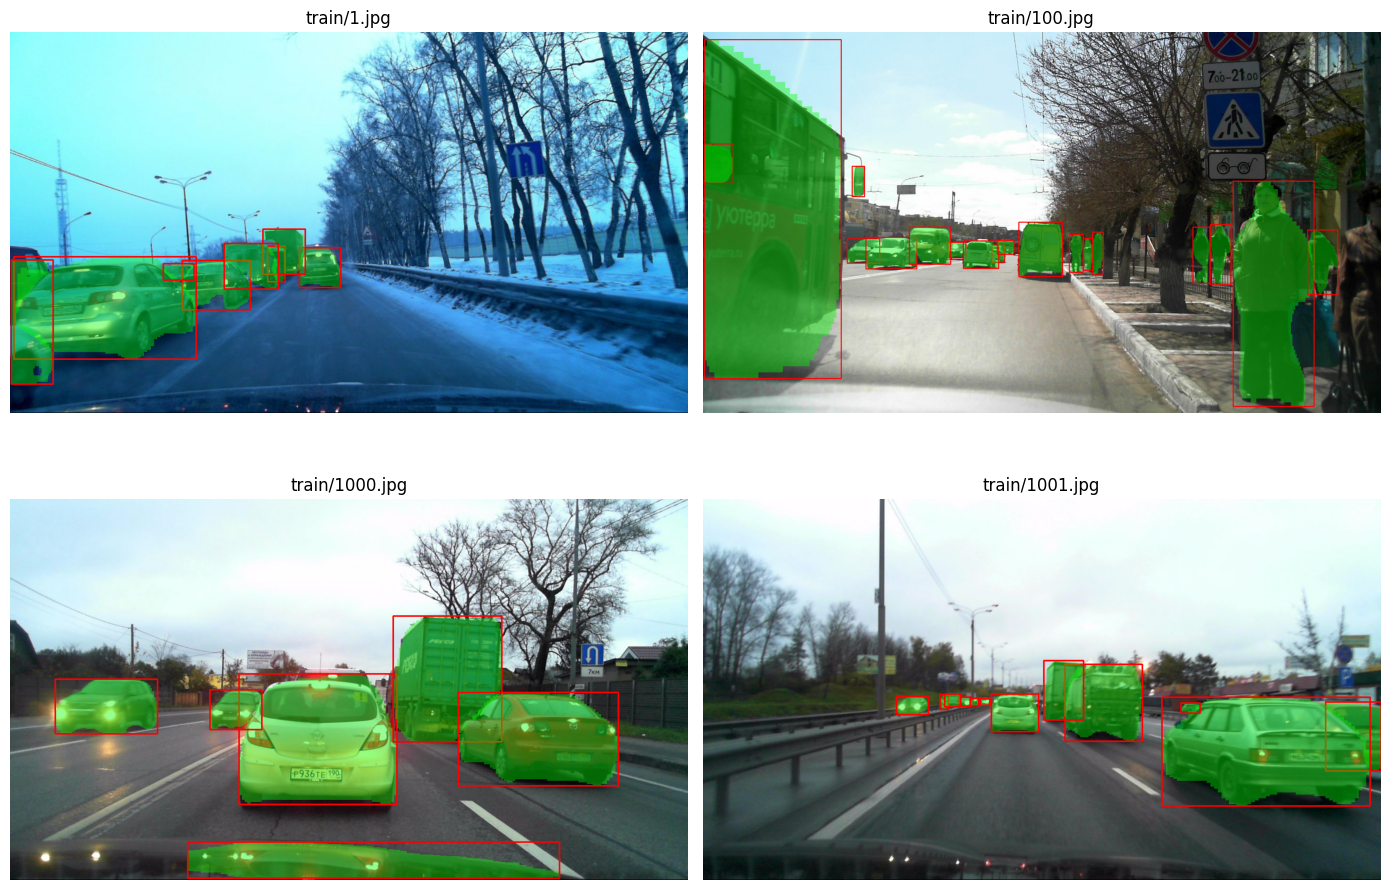

In [6]:
def ann_to_mask(ann, h, w):
    segm = ann.get('segmentation', None)
    if segm is None:
        return np.zeros((h, w), dtype=np.uint8)

    if isinstance(segm, list):
        rles = mask_utils.frPyObjects(segm, h, w)
        rle = mask_utils.merge(rles)
        m = mask_utils.decode(rle)
        return m.astype(np.uint8)

    if isinstance(segm, dict):
        m = mask_utils.decode(segm)
        if m.ndim == 3:
            m = m[..., 0]
        return m.astype(np.uint8)

    return np.zeros((h, w), dtype=np.uint8)

sample_coco = COCO(str(PROCESSED_DIR / 'train_8_classes.json'))
sample_ids = sample_coco.getImgIds()[:4]

plt.figure(figsize=(14, 10))
for i, img_id in enumerate(sample_ids, start=1):
    img_info = sample_coco.loadImgs([img_id])[0]
    img_path = IMAGES_ROOT / img_info['file_name']
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    anns = sample_coco.loadAnns(sample_coco.getAnnIds(imgIds=[img_id]))
    overlay = img.copy()

    for ann in anns:
        m = ann_to_mask(ann, img_info['height'], img_info['width'])
        color = np.array([0, 255, 0], dtype=np.uint8)
        overlay[m > 0] = (0.6 * overlay[m > 0] + 0.4 * color).astype(np.uint8)

        x, y, bw, bh = ann['bbox']
        cv2.rectangle(overlay, (int(x), int(y)), (int(x + bw), int(y + bh)), (255, 0, 0), 2)

    plt.subplot(2, 2, i)
    plt.imshow(overlay)
    plt.title(img_info['file_name'])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 6) Выбор предобученной модели и подготовка данных под YOLO-seg

In [7]:
def link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except Exception:
        shutil.copy2(src, dst)


def rle_to_polygons(segm, h, w):
    m = mask_utils.decode(segm)
    if m.ndim == 3:
        m = m[..., 0]
    m = m.astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in contours:
        if len(c) >= 3:
            poly = c.reshape(-1, 2).astype(float).flatten().tolist()
            if len(poly) >= 6:
                polys.append(poly)
    return polys


def coco_to_yolo_seg(split_name: str, max_images=None):
    split_json = PROCESSED_DIR / f'{split_name}_8_classes.json'
    coco_split = COCO(str(split_json))

    categories = coco_split.loadCats(coco_split.getCatIds())
    categories = sorted(categories, key=lambda x: x['id'])
    cat_to_yolo = {c['id']: i for i, c in enumerate(categories)}
    names = [c['name'] for c in categories]

    with open(PROCESSED_DIR / 'cat_to_yolo.json', 'w', encoding='utf-8') as f:
        json.dump({'cat_to_yolo': cat_to_yolo, 'names': names}, f, ensure_ascii=False, indent=2)

    yolo_img_dir = YOLO_DIR / 'images' / split_name
    yolo_lbl_dir = YOLO_DIR / 'labels' / split_name
    yolo_img_dir.mkdir(parents=True, exist_ok=True)
    yolo_lbl_dir.mkdir(parents=True, exist_ok=True)

    img_ids = coco_split.getImgIds()
    if max_images is not None:
        img_ids = img_ids[:max_images]

    for img_id in img_ids:
        img_info = coco_split.loadImgs([img_id])[0]
        src_img = IMAGES_ROOT / img_info['file_name']
        if not src_img.exists():
            # fallback: ищем по имени
            cand = list(IMAGES_ROOT.rglob(Path(img_info['file_name']).name))
            if not cand:
                continue
            src_img = cand[0]

        dst_img = yolo_img_dir / Path(img_info['file_name']).name
        link_or_copy(src_img, dst_img)

        h, w = img_info['height'], img_info['width']
        anns = coco_split.loadAnns(coco_split.getAnnIds(imgIds=[img_id]))

        lines = []
        for ann in anns:
            cid = ann['category_id']
            if cid not in cat_to_yolo:
                continue
            cls = cat_to_yolo[cid]

            segm = ann.get('segmentation', None)
            polys = []
            if isinstance(segm, list):
                polys = segm
            elif isinstance(segm, dict):
                polys = rle_to_polygons(segm, h, w)

            for poly in polys:
                if len(poly) < 6:
                    continue
                norm = []
                for i, v in enumerate(poly):
                    if i % 2 == 0:
                        norm.append(v / w)
                    else:
                        norm.append(v / h)
                line = str(cls) + ' ' + ' '.join(f'{x:.6f}' for x in norm)
                lines.append(line)

        lbl_path = yolo_lbl_dir / (Path(img_info['file_name']).stem + '.txt')
        with open(lbl_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))

    return names

MAX_IMAGES_PER_SPLIT = None  # поставь число (например 20000), если нужно ускорить
class_names = coco_to_yolo_seg('train', MAX_IMAGES_PER_SPLIT)
_ = coco_to_yolo_seg('val', MAX_IMAGES_PER_SPLIT)
_ = coco_to_yolo_seg('test', MAX_IMAGES_PER_SPLIT)

DATA_YAML = YOLO_DIR / 'data.yaml'
with open(DATA_YAML, 'w', encoding='utf-8') as f:
    f.write(
        f"path: {YOLO_DIR.as_posix()}\n"
        "train: images/train\n"
        "val: images/val\n"
        "test: images/test\n"
        f"nc: {len(class_names)}\n"
        f"names: {class_names}\n"
    )

print('YOLO data.yaml:', DATA_YAML)
print('Classes:', class_names)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


YOLO data.yaml: /home/flicky/itmo/mlcv-itmo/lab-6/data/yolo_seg/data.yaml
Classes: ['pedestrian_crossing', 'bicycle_path', 'parking', 'no_entry', 'bus_stop', 'no_trucks', 'traffic_light_ahead', 'stop']


## 7) Обучение модели сегментации

In [8]:
MODEL_WEIGHTS = 'yolov8n-seg.pt'

if DEVICE == 'cuda':
    IMG_SIZE = 640
    BATCH = 16
    EPOCHS = 60
else:
    IMG_SIZE = 512
    BATCH = 2
    EPOCHS = 18  # ~40-60 минут на CPU

PROJECT_DIR = ROOT / 'lab-6' / 'runs'
RUN_NAME = 'russian_signs_seg'

print(f'Training config: device={DEVICE}, imgsz={IMG_SIZE}, batch={BATCH}, epochs={EPOCHS}')

model = YOLO(MODEL_WEIGHTS)

_prev_best = PROJECT_DIR / RUN_NAME / 'weights' / 'best.pt'
if _prev_best.exists():
    print('Веса уже есть, пропускаем переобучение:', _prev_best)
    class _FakeResult:
        save_dir = PROJECT_DIR / RUN_NAME
    train_result = _FakeResult()
else:
    train_result = model.train(
    data=str(DATA_YAML),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH,
    device=0 if DEVICE == 'cuda' else 'cpu',
    workers=4 if DEVICE == 'cuda' else 0,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    patience=EPOCHS,
    seed=SEED,
    plots=False,
    verbose=False,
    )

best_weights = Path(train_result.save_dir) / 'weights' / 'best.pt'
last_weights = Path(train_result.save_dir) / 'weights' / 'last.pt'
print('best:', best_weights)


Training config: device=cpu, imgsz=512, batch=2, epochs=18
Веса уже есть, пропускаем переобучение: /home/flicky/itmo/mlcv-itmo/lab-6/runs/russian_signs_seg/weights/best.pt
best: /home/flicky/itmo/mlcv-itmo/lab-6/runs/russian_signs_seg/weights/best.pt


## 8) Инференс на валидационной выборке

In [9]:
seg_model = YOLO(str(best_weights if best_weights.exists() else MODEL_WEIGHTS))
seg_model.model.names = {i: n for i, n in enumerate(class_names)}  # веса помнят старые имена с обучения, переопределяем

val_metrics_native = seg_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0 if DEVICE == 'cuda' else 'cpu',
    plots=False,
    verbose=False,
)

if hasattr(val_metrics_native, 'results_dict'):
    native_df = pd.Series(val_metrics_native.results_dict, name='value').to_frame()
    display(native_df)
else:
    print(val_metrics_native)

Ultralytics 8.4.35 🚀 Python-3.14.5 torch-2.10.0+cu128 CPU (AMD Ryzen 7 7840HS w/ Radeon 780M Graphics)


YOLOv8n-seg summary (fused): 86 layers, 3,259,624 parameters, 0 gradients, 11.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 141.2±76.0 MB/s, size: 190.0 KB)


val: Scanning /home/flicky/itmo/mlcv-itmo/lab-6/data/yolo_seg/labels/val... 209 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 209/209 2.1Kit/s 0.1s

val: New cache created: /home/flicky/itmo/mlcv-itmo/lab-6/data/yolo_seg/labels/val.cache


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 99% ━━━━━━━━━━━╸ 104/105 16.5it/s 4.7s<0.1s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 105/105 21.8it/s 4.8s

                   all        209       1474      0.352      0.294      0.307      0.207       0.32      0.289      0.281      0.162


Speed: 0.2ms preprocess, 13.4ms inference, 0.0ms loss, 2.2ms postprocess per image


,value
metrics/precision(B),0.351882
metrics/recall(B),0.294494
metrics/mAP50(B),0.306774
metrics/mAP50-95(B),0.207480
metrics/precision(M),0.320484
metrics/recall(M),0.288862
metrics/mAP50(M),0.280588
metrics/mAP50-95(M),0.162364
fitness,0.369844


## 9) Расчет метрик IoU, Precision, Recall, L2

In [10]:
with open(PROCESSED_DIR / 'cat_to_yolo.json', 'r', encoding='utf-8') as f:
    map_info = json.load(f)
cat_to_yolo = {int(k): int(v) for k, v in map_info['cat_to_yolo'].items()}
yolo_names = map_info['names']

val_coco = COCO(str(PROCESSED_DIR / 'val_8_classes.json'))


def mask_metrics(pred: np.ndarray, gt: np.ndarray):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()

    union = tp + fp + fn
    iou = tp / union if union > 0 else 1.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 1.0
    l2 = np.sqrt(np.mean((pred.astype(np.float32) - gt.astype(np.float32)) ** 2))
    return iou, precision, recall, l2


def build_gt_masks_by_class(coco_obj, img_id, h, w, cat_to_yolo_map):
    anns = coco_obj.loadAnns(coco_obj.getAnnIds(imgIds=[img_id]))
    class_masks = {c: np.zeros((h, w), dtype=np.uint8) for c in set(cat_to_yolo_map.values())}

    for ann in anns:
        cid = ann['category_id']
        if cid not in cat_to_yolo_map:
            continue
        yc = cat_to_yolo_map[cid]
        m = ann_to_mask(ann, h, w)
        class_masks[yc] = np.maximum(class_masks[yc], m)

    global_mask = np.zeros((h, w), dtype=np.uint8)
    for m in class_masks.values():
        global_mask = np.maximum(global_mask, m)

    return class_masks, global_mask


def build_pred_masks_by_class(result, h, w, n_classes):
    class_masks = {c: np.zeros((h, w), dtype=np.uint8) for c in range(n_classes)}

    if result.masks is None or result.boxes is None:
        return class_masks, np.zeros((h, w), dtype=np.uint8)

    masks = result.masks.data.cpu().numpy()  # N, Hm, Wm
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)

    for m, c in zip(masks, cls_ids):
        m = (m > 0.5).astype(np.uint8)
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        if c in class_masks:
            class_masks[c] = np.maximum(class_masks[c], m)

    global_mask = np.zeros((h, w), dtype=np.uint8)
    for m in class_masks.values():
        global_mask = np.maximum(global_mask, m)

    return class_masks, global_mask


val_rows = []
per_class_rows = []

val_img_ids = val_coco.getImgIds()
for img_id in val_img_ids:
    img_info = val_coco.loadImgs([img_id])[0]
    h, w = img_info['height'], img_info['width']

    img_path = IMAGES_ROOT / img_info['file_name']
    if not img_path.exists():
        cand = list(IMAGES_ROOT.rglob(Path(img_info['file_name']).name))
        if not cand:
            continue
        img_path = cand[0]

    pred = seg_model.predict(source=str(img_path), imgsz=IMG_SIZE, conf=0.25, iou=0.7, verbose=False)[0]

    gt_by_class, gt_global = build_gt_masks_by_class(val_coco, img_id, h, w, cat_to_yolo)
    pr_by_class, pr_global = build_pred_masks_by_class(pred, h, w, len(yolo_names))

    iou, precision, recall, l2 = mask_metrics(pr_global, gt_global)
    val_rows.append({
        'image_id': img_id,
        'file_name': img_info['file_name'],
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'l2': l2
    })

    for c in range(len(yolo_names)):
        # считаем только там, где класс реально есть в разметке — иначе редкие классы
        # получают iou=1.0 просто за счёт "пусто против пусто" на всех остальных кадрах
        gt_present = gt_by_class[c].any()
        if not gt_present:
            continue
        ciou, cprec, crec, cl2 = mask_metrics(pr_by_class[c], gt_by_class[c])
        per_class_rows.append({
            'image_id': img_id,
            'class_id': c,
            'class_name': yolo_names[c],
            'iou': ciou,
            'precision': cprec,
            'recall': crec,
            'l2': cl2
        })

val_df = pd.DataFrame(val_rows)
val_class_df = pd.DataFrame(per_class_rows)

print('Val images evaluated:', len(val_df))
print('Val mean metrics:')
print(val_df[['iou', 'precision', 'recall', 'l2']].mean())

print('\nPer-class mean metrics (only images where the class is present in GT; support = number of such images):')
per_class_summary = val_class_df.groupby(['class_id', 'class_name'])[['iou', 'precision', 'recall', 'l2']].mean()
per_class_summary['support'] = val_class_df.groupby(['class_id', 'class_name']).size()
display(per_class_summary.reset_index())

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Val images evaluated: 209
Val mean metrics:
iou          0.579245
precision    0.663215
recall       0.817656
l2           0.138823
dtype: float64

Per-class mean metrics (only images where the class is present in GT; support = number of such images):


,class_id,class_name,iou,precision,recall,l2,support
0,0,pedestrian_crossing,0.189460,0.824270,0.305540,0.041774,73
1,1,bicycle_path,0.000000,1.000000,0.000000,0.043153,2
2,2,parking,0.571364,0.626417,0.855465,0.122425,197
3,3,no_entry,0.000000,1.000000,0.000000,0.028736,1
4,4,bus_stop,0.154126,0.974391,0.179053,0.105863,11
5,5,no_trucks,0.464345,0.795904,0.605781,0.092032,99
6,6,traffic_light_ahead,0.193479,0.775907,0.324241,0.040724,39
7,7,stop,0.000000,1.000000,0.000000,0.020145,1


### Сравнение со стоковой моделью

Наши 8 классов — это COCO-категории, их и так находит обычная предобученная модель.
Чтобы показать, что дообучение реально что-то дало, сравниваем нашу модель со стоковым
`yolov8n-seg.pt` (без fine-tuning) на тех же val-фото и тех же метриках.


In [11]:
baseline_model = YOLO('yolov8n-seg.pt')  # исходные COCO-веса, без fine-tuning на нашем датасете

# Мапим имена наших классов на индексы стоковой COCO-модели (у неё свой порядок из 80 классов).
coco_name_fix = {'traffic_light': 'traffic light', 'stop_sign': 'stop sign'}
baseline_name_to_idx = {name: idx for idx, name in baseline_model.names.items()}
our_to_baseline_idx = {}
for our_idx, name in enumerate(yolo_names):
    coco_name = coco_name_fix.get(name, name)
    if coco_name in baseline_name_to_idx:
        our_to_baseline_idx[our_idx] = baseline_name_to_idx[coco_name]
print('Class index mapping (ours -> stock COCO model):', our_to_baseline_idx)


def build_pred_masks_by_class_remapped(result, h, w, n_classes, idx_map):
    """Как build_pred_masks_by_class, но переводит id классов стоковой модели в наши id."""
    class_masks = {c: np.zeros((h, w), dtype=np.uint8) for c in range(n_classes)}
    if result.masks is None or result.boxes is None:
        return class_masks, np.zeros((h, w), dtype=np.uint8)

    masks = result.masks.data.cpu().numpy()
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    reverse_map = {v: k for k, v in idx_map.items()}

    for m, c in zip(masks, cls_ids):
        our_c = reverse_map.get(int(c))
        if our_c is None:
            continue
        m = (m > 0.5).astype(np.uint8)
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        class_masks[our_c] = np.maximum(class_masks[our_c], m)

    global_mask = np.zeros((h, w), dtype=np.uint8)
    for m in class_masks.values():
        global_mask = np.maximum(global_mask, m)
    return class_masks, global_mask


baseline_rows = []
for img_id in val_img_ids:
    img_info = val_coco.loadImgs([img_id])[0]
    h, w = img_info['height'], img_info['width']
    img_path = IMAGES_ROOT / img_info['file_name']
    if not img_path.exists():
        cand = list(IMAGES_ROOT.rglob(Path(img_info['file_name']).name))
        if not cand:
            continue
        img_path = cand[0]

    pred = baseline_model.predict(source=str(img_path), imgsz=IMG_SIZE, conf=0.25, iou=0.7, verbose=False)[0]
    _, gt_global = build_gt_masks_by_class(val_coco, img_id, h, w, cat_to_yolo)
    _, pr_global = build_pred_masks_by_class_remapped(pred, h, w, len(yolo_names), our_to_baseline_idx)

    iou, precision, recall, l2 = mask_metrics(pr_global, gt_global)
    baseline_rows.append({'image_id': img_id, 'iou': iou, 'precision': precision, 'recall': recall, 'l2': l2})

baseline_df = pd.DataFrame(baseline_rows)

compare_df = pd.DataFrame({
    'finetuned': val_df[['iou', 'precision', 'recall', 'l2']].mean(),
    'stock_coco_pretrained (no fine-tuning)': baseline_df[['iou', 'precision', 'recall', 'l2']].mean(),
})
print('Дообученная модель vs стоковая COCO-модель (тот же val, те же метрики):')
display(compare_df)

Class index mapping (ours -> stock COCO model): {}


Дообученная модель vs стоковая COCO-модель (тот же val, те же метрики):


,finetuned,stock_coco_pretrained (no fine-tuning)
iou,0.579245,0.00000
precision,0.663215,1.00000
recall,0.817656,0.00000
l2,0.138823,0.21114


## 10) Доли изображений с IoU >= 0.5, 0.75, 0.9

Val threshold shares:


,threshold,share
0,0.50,0.674641
1,0.75,0.358852
2,0.90,0.043062


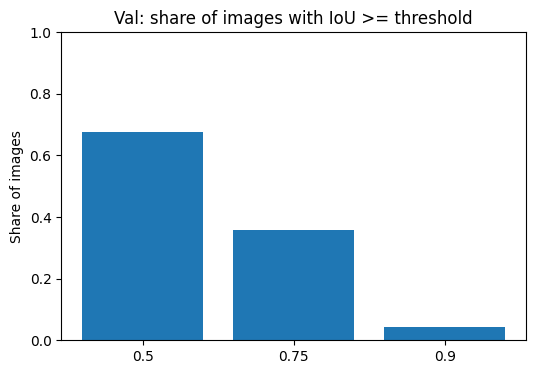

In [12]:
thresholds = [0.5, 0.75, 0.9]
threshold_stats = {
    f'iou_ge_{t}': float((val_df['iou'] >= t).mean())
    for t in thresholds
}

thr_df = pd.DataFrame([
    {'threshold': t, 'share': threshold_stats[f'iou_ge_{t}']}
    for t in thresholds
])

print('Val threshold shares:')
display(thr_df)

plt.figure(figsize=(6, 4))
plt.bar(thr_df['threshold'].astype(str), thr_df['share'])
plt.ylim(0, 1)
plt.ylabel('Share of images')
plt.title('Val: share of images with IoU >= threshold')
plt.show()

## 11) Тестирование на 10 собственных уличных фото

Custom photos found: 5
Для отчета нужно 10 фото. Сейчас: 5


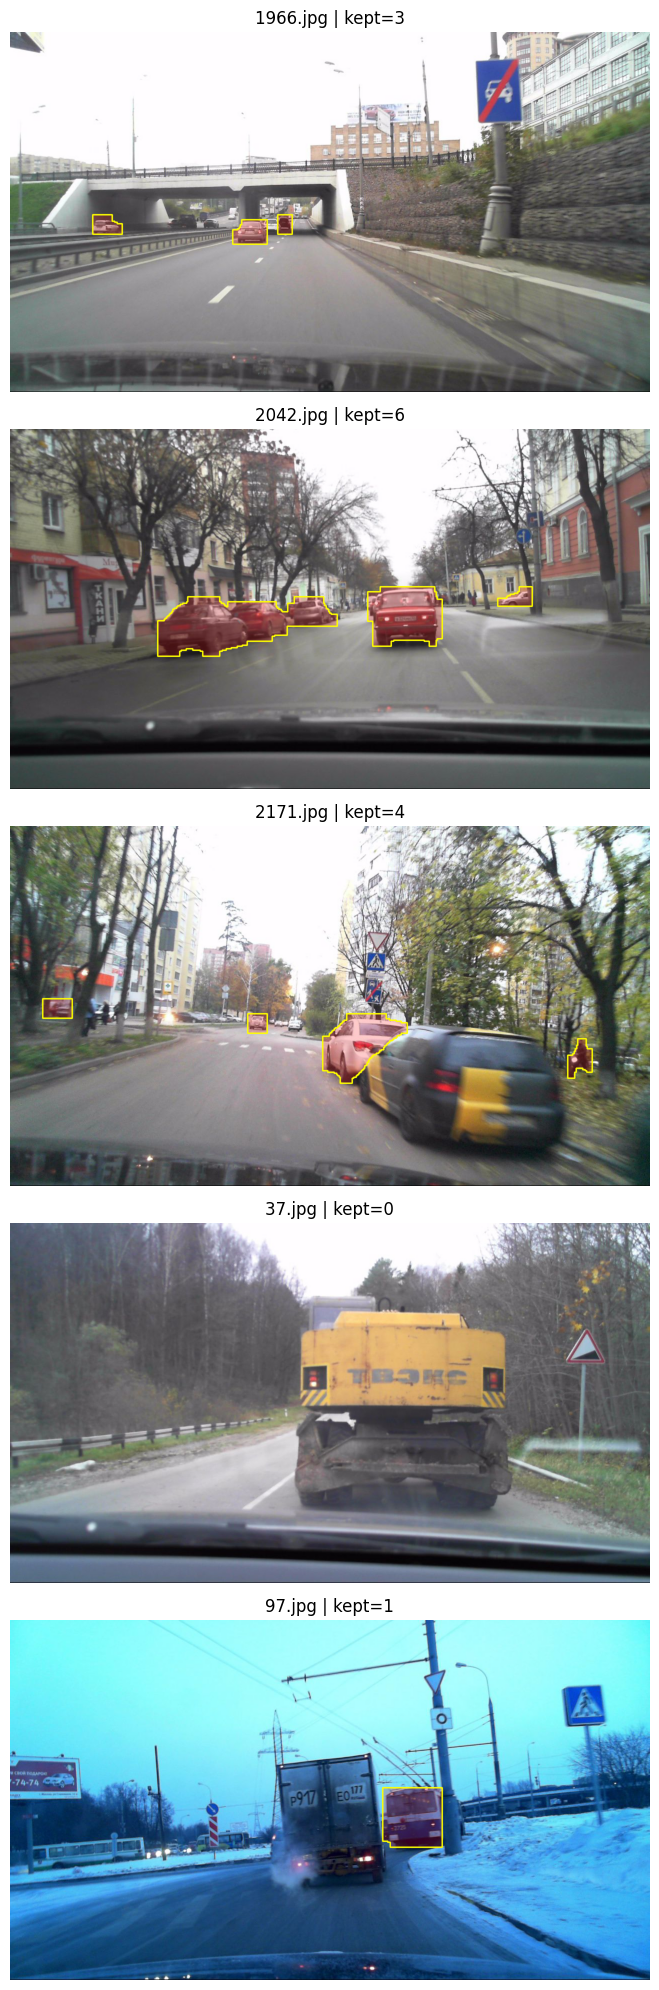

,file_name,has_gt,pred_instances
0,1966.jpg,False,3
1,2042.jpg,False,6
2,2171.jpg,False,4
3,37.jpg,False,0
4,97.jpg,False,1


In [13]:
def build_pred_masks_by_class_filtered(
    result,
    h,
    w,
    n_classes,
    conf_thr=0.45,
    min_area_px=20,
    max_area_frac=0.04,
):
    class_masks = {c: np.zeros((h, w), dtype=np.uint8) for c in range(n_classes)}

    if result.masks is None or result.boxes is None:
        return class_masks, np.zeros((h, w), dtype=np.uint8), 0

    masks = result.masks.data.cpu().numpy()
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy() if hasattr(result.boxes, 'conf') else np.ones(len(cls_ids), dtype=float)

    max_area_px = int(max_area_frac * h * w)
    kept = 0

    for m, c, conf in zip(masks, cls_ids, confs):
        if conf < conf_thr:
            continue

        m = (m > 0.5).astype(np.uint8)
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

        area = int(m.sum())
        if area < min_area_px or area > max_area_px:
            continue

        if c in class_masks:
            class_masks[c] = np.maximum(class_masks[c], m)
            kept += 1

    global_mask = np.zeros((h, w), dtype=np.uint8)
    for m in class_masks.values():
        global_mask = np.maximum(global_mask, m)

    return class_masks, global_mask, kept


photo_paths = sorted([p for p in CUSTOM_PHOTOS_DIR.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}])
print('Custom photos found:', len(photo_paths))
if len(photo_paths) and len(photo_paths) != 10:
    print('Для отчета нужно 10 фото. Сейчас:', len(photo_paths))

custom_rows = []

if len(photo_paths):
    plt.figure(figsize=(14, 4 * len(photo_paths)))

for i, p in enumerate(photo_paths, start=1):
    res = seg_model.predict(
        source=str(p),
        imgsz=IMG_SIZE,
        conf=0.45,
        iou=0.6,
        max_det=25,
        verbose=False,
    )[0]

    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    _, pred_global, kept = build_pred_masks_by_class_filtered(
        res,
        h,
        w,
        len(yolo_names),
        conf_thr=0.45,
        min_area_px=20,
        max_area_frac=0.04,
    )

    gt_mask_path = CUSTOM_MASKS_DIR / f'{p.stem}.png'
    has_gt = gt_mask_path.exists()

    row = {'file_name': p.name, 'has_gt': has_gt, 'pred_instances': kept}
    if has_gt:
        gt = cv2.imread(str(gt_mask_path), cv2.IMREAD_GRAYSCALE)
        gt = cv2.resize(gt, (w, h), interpolation=cv2.INTER_NEAREST)
        gt = (gt > 127).astype(np.uint8)

        iou, precision, recall, l2 = mask_metrics(pred_global, gt)
        row.update({'iou': iou, 'precision': precision, 'recall': recall, 'l2': l2})

    custom_rows.append(row)

    overlay = img.copy()
    if pred_global.any():
        overlay[pred_global > 0] = (0.8 * overlay[pred_global > 0] + 0.2 * np.array([255, 0, 0])).astype(np.uint8)
        contours, _ = cv2.findContours(pred_global.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 255, 0), 2)

    plt.subplot(len(photo_paths), 1, i)
    plt.imshow(overlay)
    title = f"{p.name} | kept={kept}"
    if has_gt:
        title += f" | IoU={row['iou']:.3f}, P={row['precision']:.3f}, R={row['recall']:.3f}, L2={row['l2']:.3f}"
    plt.title(title)
    plt.axis('off')

if len(photo_paths):
    plt.tight_layout()
    plt.show()

custom_df = pd.DataFrame(custom_rows)
if len(custom_df):
    display(custom_df)
else:
    print('Custom block skipped: добавь свои фото в street-photos.')

if len(custom_df) and custom_df['has_gt'].any():
    custom_eval_df = custom_df[custom_df['has_gt']].copy()
    print('Custom mean metrics (only images with GT masks):')
    print(custom_eval_df[['iou', 'precision', 'recall', 'l2']].mean())

    custom_thr_df = pd.DataFrame([
        {'threshold': t, 'share': float((custom_eval_df['iou'] >= t).mean())}
        for t in thresholds
    ])
    print('\nCustom threshold shares:')
    display(custom_thr_df)

### Классическая проверка: детекция знаков по цвету/форме

YOLO-модель выше обучена на COCO-категориях этого датасета (person/car/bus/...), а не на типах знаков
(см. пункт 2) — на реальных фото она честно находит машины/людей, а не знаки. Отдельно, классическим
способом (HSV-пороги по красному/синему + фильтр по форме контура — та же идея, что в лабе 2), находим
именно знаки: они почти всегда яркого красного/синего цвета и имеют форму круга/треугольника/квадрата.

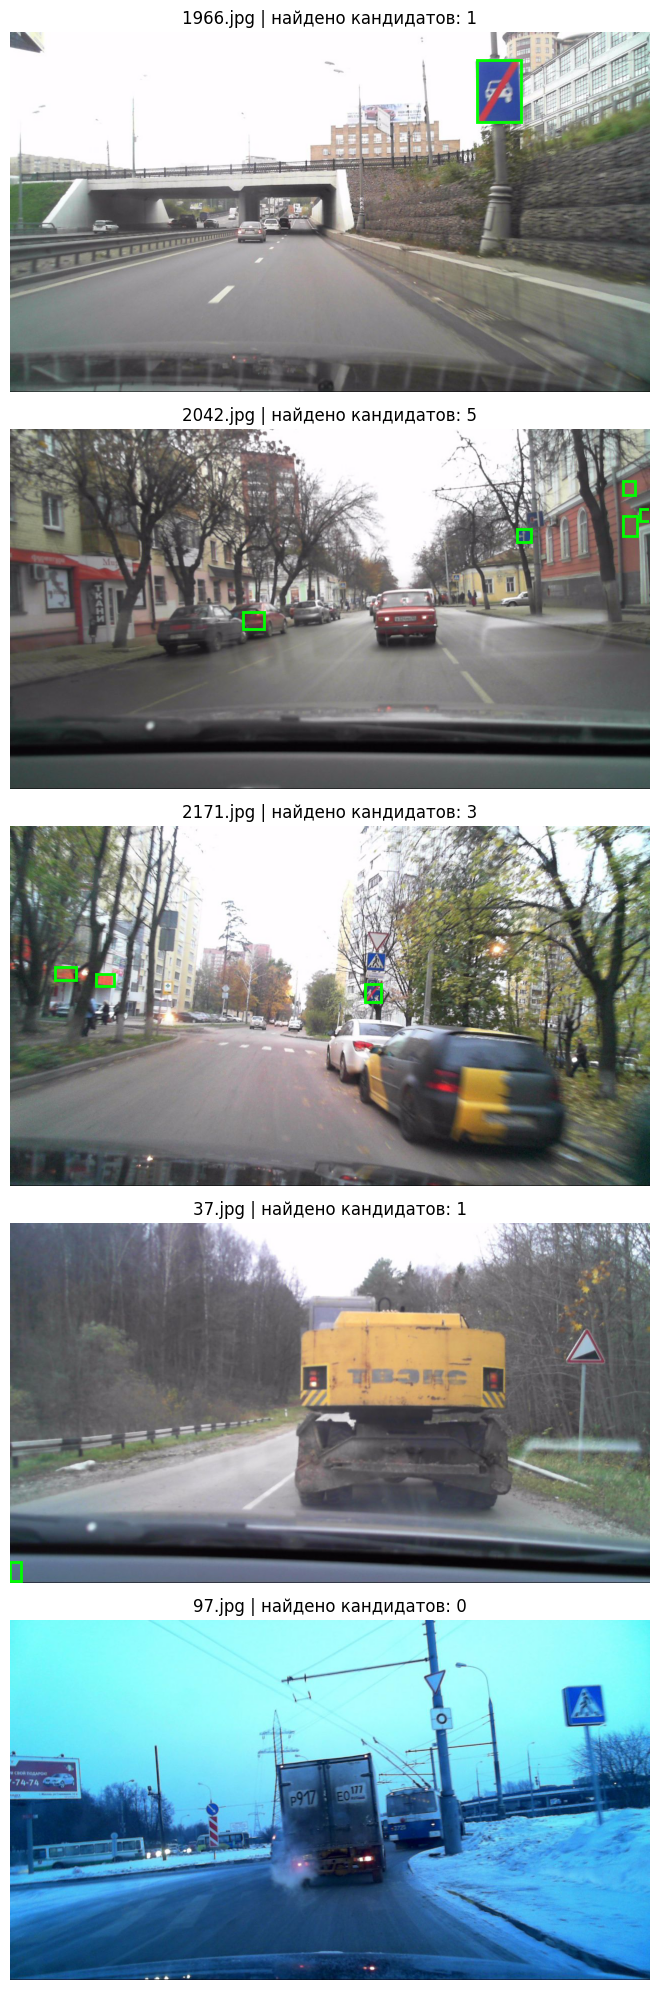

In [14]:
def detect_signs_classical(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    red = cv2.inRange(hsv, (0, 90, 60), (10, 255, 255)) | cv2.inRange(hsv, (170, 90, 60), (180, 255, 255))
    blue = cv2.inRange(hsv, (95, 90, 60), (130, 255, 255))
    mask = red | blue

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h_img, w_img = img_bgr.shape[:2]
    boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 250 or area > 0.05 * h_img * w_img:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        if not (0.5 < w / max(h, 1) < 2.0):
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0 or 4 * np.pi * area / (perimeter ** 2) < 0.35:
            continue  # знаки - компактные фигуры (круг/треугольник/квадрат), не произвольные кляксы
        boxes.append((x, y, w, h))
    return boxes


photo_paths_classical = sorted([p for p in CUSTOM_PHOTOS_DIR.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
if photo_paths_classical:
    plt.figure(figsize=(14, 4 * len(photo_paths_classical)))
    for i, p in enumerate(photo_paths_classical, start=1):
        img = cv2.imread(str(p))
        boxes = detect_signs_classical(img)

        plt.subplot(len(photo_paths_classical), 1, i)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        for x, y, w, h in boxes:
            plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, color='lime', linewidth=2))
        plt.title(f'{p.name} | найдено кандидатов: {len(boxes)}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 12) Итоги, визуализация метрик и очистка промежуточных файлов

,val_iou,val_precision,val_recall,val_l2,iou_ge_0.5,iou_ge_0.75,iou_ge_0.9
0,0.579245,0.663215,0.817656,0.138823,0.674641,0.358852,0.043062


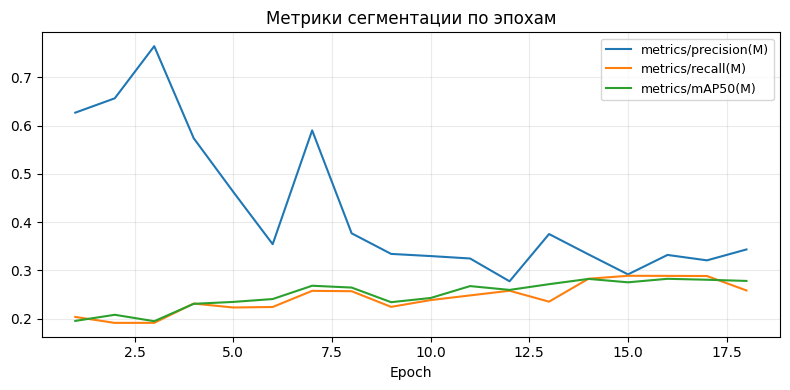

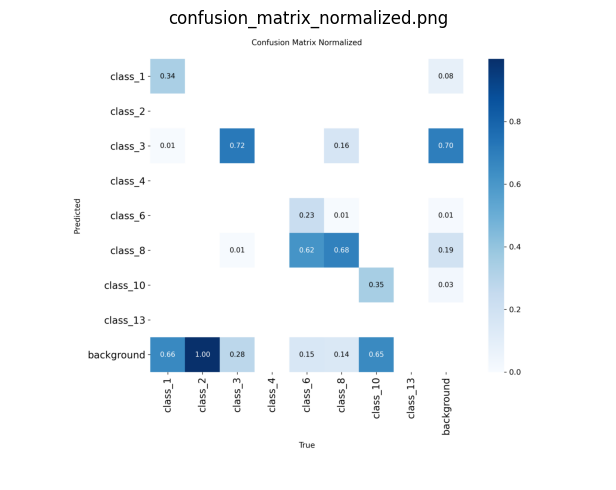

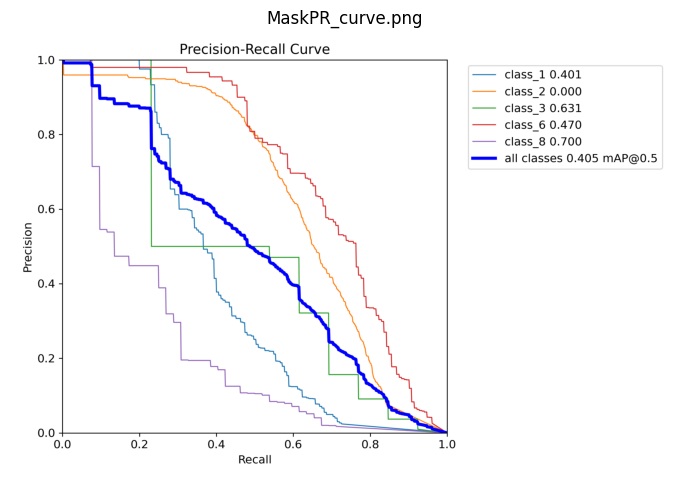

In [15]:
summary = {
    'weights_best': str(best_weights),
    'weights_last': str(last_weights),
    'data_yaml': str(DATA_YAML),
    'val_mean_metrics': val_df[['iou', 'precision', 'recall', 'l2']].mean().to_dict(),
    'val_threshold_shares': {k: float(v) for k, v in threshold_stats.items()},
}

if 'custom_df' in globals() and len(custom_df) and custom_df['has_gt'].any():
    custom_eval_df = custom_df[custom_df['has_gt']]
    summary['custom_mean_metrics'] = custom_eval_df[['iou', 'precision', 'recall', 'l2']].mean().to_dict()

summary_df = pd.DataFrame([
    {
        **{f'val_{k}': v for k, v in summary['val_mean_metrics'].items()},
        **summary['val_threshold_shares'],
    }
])
display(summary_df)

run_dir = Path(train_result.save_dir)

results_csv = run_dir / 'results.csv'
if results_csv.exists():
    hist = pd.read_csv(results_csv)
    x = hist['epoch'] if 'epoch' in hist.columns else np.arange(1, len(hist) + 1)
    seg_metric_cols = [c for c in ['metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)'] if c in hist.columns]

    plt.figure(figsize=(8, 4))
    for c in seg_metric_cols:
        plt.plot(x, hist[c], label=c)
    plt.title('Метрики сегментации по эпохам')
    plt.xlabel('Epoch')
    plt.grid(alpha=0.25)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# confusion matrix и PR-кривая по маскам - самое информативное, без остального (box-метрики тут не главные)
for name in ['confusion_matrix_normalized.png', 'MaskPR_curve.png']:
    img_path = run_dir / name
    if img_path.exists():
        plt.figure(figsize=(7, 5))
        plt.imshow(plt.imread(img_path))
        plt.title(name)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# зачистка промежуточных файлов
for pattern in ['train_batch*.jpg', 'val_batch*_labels.jpg', 'val_batch*_pred.jpg', 'labels.jpg']:
    for p in run_dir.glob(pattern):
        p.unlink(missing_ok=True)
for p in (YOLO_DIR / 'labels').glob('*.cache'):
    p.unlink(missing_ok=True)
